<a href="https://colab.research.google.com/github/DianaSerrano1/MVP-AnalisedeDados/blob/main/An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas_MVP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Dados e Boas Práticas - MVP

**Aluno:** Diana Serrano  
**Disciplina:** Análise de Dados e Boas Práticas  
**Objetivo:** Analisar o comportamento da demanda de malas de bordo e preparar a base para modelagem preditiva.

**Reprodutibilidade:** Este notebook pode ser executado a partir do dataset disponibilizado no repositório.
https://github.com/DianaSerrano1/MVP-AnalisedeDados.git

# 1- Descrição do Problema

O trabalho tem como objetivo analisar o comportamento de vendas da categoria de malas de bordo em uma rede varejista, com foco em entender como variações de preço influenciam a quantidade vendida ao longo do tempo.

Diferentemente de abordagens tradicionais focadas em classificação, este estudo busca compreender a relação entre preço e demanda, utilizando dados históricos de vendas em nível transacional. A partir dessa análise, pretende-se preparar um dataset adequado para futuras aplicações de modelos de previsão, que possam apoiar decisões de precificação.

Cabe destacar que as variações de preço observadas no dataset podem estar associadas a ações promocionais e campanhas comerciais, que não estão explicitamente identificadas nos dados. Dessa forma, o impacto do preço sobre a quantidade vendida deve ser interpretado como um efeito combinado entre preço e fatores promocionais implícitos.

##1.1- Hipóteses do Problema

As hipóteses consideradas para este estudo são as seguintes:


Reduções de preço, possivelmente associadas a promoções, estão relacionadas a aumentos na quantidade vendida.
A relação entre preço e quantidade vendida não é necessariamente linear, podendo apresentar comportamentos distintos em diferentes faixas de preço.
Existem padrões temporais na demanda, como variações ao longo dos dias da semana e sazonalidade mensal.
Parte da variação da quantidade vendida pode ser explicada por fatores não observáveis no dataset, como campanhas promocionais e disponibilidade de estoque.

1. **A quantidade vendida de malas de bordo varia em função do preço praticado ao longo do tempo.**

2. **Reduções de preço, possivelmente associadas a promoções, estão relacionadas a aumentos na quantidade vendida.**

3. **A relação entre preço e quantidade vendida não é necessariamente linear, podendo apresentar comportamentos distintos em diferentes faixas de preço.**

4. **Existem padrões temporais na demanda, como variações ao longo dos dias da semana e sazonalidade mensal.**

5. **Parte da variação da quantidade vendida pode ser explicada por fatores não observáveis no dataset, como campanhas promocionais e disponibilidade de estoque.**

##1.2- Tipo de Problema

Este é um problema de **regressão supervisionada.**

Dado um conjunto de variáveis explicativas, como preço e atributos temporais, o objetivo é prever a quantidade vendida de um produto em um determinado período.

Essa abordagem permite estimar a demanda do produto em diferentes cenários de preço, possibilitando análises futuras relacionadas à elasticidade e otimização de receita.

##1.3- Seleção de Dados

O dataset utilizado neste trabalho será construído a partir de dados transacionais de vendas da empresa, contendo informações detalhadas de cada item vendido.

Diferentemente de datasets prontos, os dados serão extraídos de uma base operacional e posteriormente tratados e agregados para o nível analítico desejado. A análise será restrita à categoria de malas de bordo, garantindo maior consistência no comportamento dos produtos analisados.

O período de análise será definido de forma a garantir volume suficiente de dados e presença de variações de preço ao longo do tempo, condição essencial para a análise proposta.

##1.4 Atributos do Dataset


O dataset será estruturado no nível de produto por dia, contendo os seguintes atributos:

- ***DATA: data da venda***
- ***SKU: identificador do produto***  (mala de bordo)
- ***DESC_SKU: Nome do produto***
- ***QUANTIDADE_VENDIDA: quantidade total vendida no dia***  (variável alvo)
- ***VALOR_TOTAL: valor total de vendas do produto no dia***
- ***PRECO_UNITARIO: preço médio praticado no dia***  (calculado como valor total dividido pela quantidade)
- ***DIA_SEMANA: dia da semana da venda***
- ***MES: mês da venda***
- ***ANO: ano da venda***
- ***FIM_DE_SEMANA: indicador se o dia corresponde a sábado ou domingo***

#2- Importação das Bibliotecas Necessárias e importação e Preparação Inicial dos Dados

Esta seção consolida as bibliotecas necessárias para a análise,
visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset de vendas da categoria mala de bordo.

Tambem foram realizadas transformações iniciais nos dados com o objetivo de garantir sua correta leitura e estruturação, incluindo conversão de tipos e tratamento de formatação.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



In [ ]:
# carregamento do dataset

#from google.colab import drive
#drive.mount('/content/drive')
# Ajuste o nome do arquivo se necessário
df = pd.read_csv('https://raw.githubusercontent.com/DianaSerrano1/MVP-AnalisedeDados/refs/heads/main/Analise_MalaBordo.csv', sep=';')

# Visualização inicial
print("Primeiras linhas do dataset:")
display(df.head())

Primeiras linhas do dataset:


,DATA_EMISSAO,SKU,DESCRI_SKU,QUANTIDADE_VENDIDA,VALOR_TOTAL,PRECO_UNITARIO
0,20251121,18682458002,"MALA DOWNTOWN PEQ 18,5 PRETO PP ...",197,"35016,18","177,7471066"
1,20250912,18601458003,MALA SEUL PEQ PRETO P ...,27,"16285,71","603,1744444"
2,20250721,18465651003,MALA DE VIAGEM MICKEY 3D PEQ VERMELHO P ...,1,"399,9","399,9"
3,20250306,18433586003,MALA DE VIAGEM MONTE CARLO II PEQUENA ROSE P ...,20,"10160,67","508,0335"
4,20250504,18405458003,MALA TURQUIA PEQ 20 PRETO P ...,17,"6308,4","371,0823529"


In [ ]:

#  Estrutura inicial


print("\nDimensão do dataset:", df.shape)

print("\nTipos de dados:")
print(df.info())


Dimensão do dataset: (47426, 6)

Tipos de dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47426 entries, 0 to 47425
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   DATA_EMISSAO        47426 non-null  int64 
 1   SKU                 47426 non-null  int64 
 2   DESCRI_SKU          47426 non-null  object
 3   QUANTIDADE_VENDIDA  47426 non-null  int64 
 4   VALOR_TOTAL         47426 non-null  object
 5   PRECO_UNITARIO      47426 non-null  object
dtypes: int64(3), object(3)
memory usage: 2.2+ MB
None


In [ ]:

# Converter formato AAAAMMDD para datetime
df['DATA_EMISSAO'] = pd.to_datetime(df['DATA_EMISSAO'], format='%Y%m%d')

In [ ]:
display(df.head())

,DATA_EMISSAO,SKU,DESCRI_SKU,QUANTIDADE_VENDIDA,VALOR_TOTAL,PRECO_UNITARIO
0,2025-11-21,18682458002,"MALA DOWNTOWN PEQ 18,5 PRETO PP ...",197,"35016,18","177,7471066"
1,2025-09-12,18601458003,MALA SEUL PEQ PRETO P ...,27,"16285,71","603,1744444"
2,2025-07-21,18465651003,MALA DE VIAGEM MICKEY 3D PEQ VERMELHO P ...,1,"399,9","399,9"
3,2025-03-06,18433586003,MALA DE VIAGEM MONTE CARLO II PEQUENA ROSE P ...,20,"10160,67","508,0335"
4,2025-05-04,18405458003,MALA TURQUIA PEQ 20 PRETO P ...,17,"6308,4","371,0823529"


In [ ]:

#  Criação de variáveis temporais

# Ano, mês e dia da semana

df['ANO'] = df['DATA_EMISSAO'].dt.year
df['MES'] = df['DATA_EMISSAO'].dt.month
df['DIA_SEMANA'] = df['DATA_EMISSAO'].dt.dayofweek  # 0=Segunda, 6=Domingo

# Nome do dia (opcional, bom para gráficos)
df['NOME_DIA'] = df['DATA_EMISSAO'].dt.day_name()

# Tradução para português
mapa_dias = {
    'Monday': 'Segunda',
    'Tuesday': 'Terça',
    'Wednesday': 'Quarta',
    'Thursday': 'Quinta',
    'Friday': 'Sexta',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}

df['NOME_DIA'] = df['NOME_DIA'].map(mapa_dias)

# Flag de fim de semana
df['FIM_DE_SEMANA'] = df['DIA_SEMANA'].isin([5, 6]).astype(int)

In [ ]:
df[['DATA_EMISSAO','ANO','MES','DIA_SEMANA','NOME_DIA','FIM_DE_SEMANA']].head(10)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47426 entries, 0 to 47425
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   DATA_EMISSAO        47426 non-null  datetime64[ns]
 1   SKU                 47426 non-null  int64         
 2   DESCRI_SKU          47426 non-null  object        
 3   QUANTIDADE_VENDIDA  47426 non-null  int64         
 4   VALOR_TOTAL         47426 non-null  object        
 5   PRECO_UNITARIO      47426 non-null  object        
 6   ANO                 47426 non-null  int32         
 7   MES                 47426 non-null  int32         
 8   DIA_SEMANA          47426 non-null  int32         
 9   NOME_DIA            47426 non-null  object        
 10  FIM_DE_SEMANA       47426 non-null  int64         
dtypes: datetime64[ns](1), int32(3), int64(3), object(4)
memory usage: 3.4+ MB


In [ ]:

# Correção dos tipos de dados

import numpy as np

df['QUANTIDADE_VENDIDA'] = (
    df['QUANTIDADE_VENDIDA']
    .astype(str)
    .str.replace('.', '', regex=False)   # remove milhar (se existir)
    .str.replace(',', '.', regex=False)  # vírgula → ponto
    .astype(float)
)

# arredondar para baixo
df['QUANTIDADE_VENDIDA'] = np.floor(df['QUANTIDADE_VENDIDA']).astype(int)

# VALOR_TOTAL → float (tratar vírgula e milhar)
df['VALOR_TOTAL'] = (
    df['VALOR_TOTAL']
    .astype(str)
    .str.replace('.', '', regex=False)   # remove milhar
    .str.replace(',', '.', regex=False)  # troca decimal
    .astype(float)
    .round(2)
)

# PRECO_UNITARIO → float
df['PRECO_UNITARIO'] = (
    df['PRECO_UNITARIO']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
    .round(2)
)

In [ ]:
df[['QUANTIDADE_VENDIDA', 'VALOR_TOTAL','PRECO_UNITARIO' ]].head()

,QUANTIDADE_VENDIDA,VALOR_TOTAL,PRECO_UNITARIO
0,197,35016.18,177.75
1,27,16285.71,603.17
2,1,399.90,399.90
3,20,10160.67,508.03
4,17,6308.40,371.08


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47426 entries, 0 to 47425
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   DATA_EMISSAO        47426 non-null  datetime64[ns]
 1   SKU                 47426 non-null  int64         
 2   DESCRI_SKU          47426 non-null  object        
 3   QUANTIDADE_VENDIDA  47426 non-null  int64         
 4   VALOR_TOTAL         47426 non-null  float64       
 5   PRECO_UNITARIO      47426 non-null  float64       
 6   ANO                 47426 non-null  int32         
 7   MES                 47426 non-null  int32         
 8   DIA_SEMANA          47426 non-null  int32         
 9   NOME_DIA            47426 non-null  object        
 10  FIM_DE_SEMANA       47426 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(3), object(2)
memory usage: 3.4+ MB


### Ajuste do Dataset

Durante a análise exploratória inicial, foram identificados comportamentos inconsistentes nos dados, como valores negativos e volumes atípicos de venda, que não são compatíveis com o contexto de vendas no varejo.

Essa identificação foi realizada a partir da análise estatística das variáveis, especialmente ao observar valores mínimos negativos e quantidades excessivamente elevadas no dataset.

Esses indícios sugerem a presença de registros não relacionados a vendas finais, como movimentações logísticas ou operações internas (por exemplo, transferências ou registros de importação).

Dessa forma, optou-se por refinar a base de dados, considerando apenas registros representativos de vendas reais. A partir desse ajuste, uma nova versão do dataset foi utilizada nas etapas seguintes da análise, garantindo maior consistência e aderência ao problema proposto.

#3-  Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Iris, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

##Total e Tipo das Instâncias

O dataset analisado possui aproximadamente 49 mil instâncias (observações), representando o histórico de vendas da categoria de malas de bordo em nível de produto por dia.

As variáveis presentes no conjunto de dados incluem atributos numéricos e categóricos. As variáveis numéricas são representadas principalmente por QUANTIDADE_VENDIDA (inteiro), VALOR_TOTAL e PRECO_UNITARIO (valores contínuos), enquanto atributos como DESC_SKU e NOME_DIA são categóricos.

A variável DATA_EMISSAO foi convertida para o tipo datetime, permitindo a criação de atributos temporais adicionais, como ano, mês e dia da semana, que podem auxiliar na identificação de padrões sazonais.

De forma geral, o dataset apresenta boa consistência, sem valores ausentes, e com os tipos de dados adequados para análise, o que permite avançar para a etapa de exploração e visualização dos dados

In [ ]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 47426

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47426 entries, 0 to 47425
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   DATA_EMISSAO        47426 non-null  datetime64[ns]
 1   SKU                 47426 non-null  int64         
 2   DESCRI_SKU          47426 non-null  object        
 3   QUANTIDADE_VENDIDA  47426 non-null  int64         
 4   VALOR_TOTAL         47426 non-null  float64       
 5   PRECO_UNITARIO      47426 non-null  float64       
 6   ANO                 47426 non-null  int32         
 7   MES                 47426 non-null  int32         
 8   DIA_SEMANA          47426 non-null  int32         
 9   NOME_DIA            47426 non-null  object        
 10  FIM_DE_SEMANA       47426 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(3), object(2)
memory usage: 3.4+ MB
None


In [ ]:
df.describe()

,DATA_EMISSAO,SKU,QUANTIDADE_VENDIDA,VALOR_TOTAL,PRECO_UNITARIO,ANO,MES,DIA_SEMANA,FIM_DE_SEMANA
count,47426,4.742600e+04,47426.000000,47426.000000,47426.000000,47426.000000,47426.000000,47426.000000,47426.000000
mean,2025-09-16 09:42:09.093746176,1.851265e+10,9.066672,3554.171381,466.648520,2025.192595,6.733543,2.992283,0.285982
min,2025-03-01 00:00:00,1.000246e+10,1.000000,0.040000,0.040000,2025.000000,1.000000,0.000000,0.000000
25%,2025-06-25 00:00:00,1.849203e+10,1.000000,549.900000,278.900000,2025.000000,3.000000,1.000000,0.000000
50%,2025-09-20 00:00:00,1.860107e+10,4.000000,1499.900000,373.655000,2025.000000,7.000000,3.000000,0.000000
75%,2025-12-11 00:00:00,1.868446e+10,9.000000,4303.662500,524.910000,2025.000000,10.000000,5.000000,1.000000
max,2026-03-22 00:00:00,2.203395e+11,568.000000,99572.420000,6214.140000,2026.000000,12.000000,6.000000,1.000000
std,NaN,1.648528e+09,17.896797,5395.262377,383.634202,0.394342,3.477909,1.988492,0.451886


## Considerações:

- A variável preço unitário apresenta ampla variação, com valores mínimos muito baixos e máximos elevados. Esses extremos podem indicar a presença de outliers, possivelmente associados a erros de registro ou situações específicas como promoções ou produtos diferenciados.

- A variável preço unitário apresenta ampla variação, com valores mínimos muito baixos e máximos elevados. Esses extremos podem indicar a presença de outliers, possivelmente associados a erros de registro ou situações específicas como promoções ou produtos diferenciados.

 - A análise também indica a presença de possíveis outliers, tanto na variável de preço unitário quanto na quantidade vendida. Esses valores extremos podem impactar análises futuras e sugerem a necessidade de avaliação adicional durante a etapa de pré-processamento. (preço minimo = 0,04)


## 3.1- Distribuições

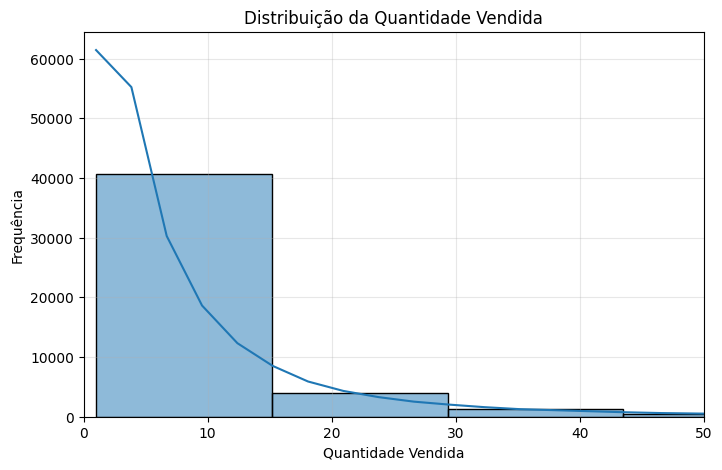

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df['QUANTIDADE_VENDIDA'], bins=40, kde=True)

plt.title('Distribuição da Quantidade Vendida')
plt.xlabel('Quantidade Vendida')
plt.ylabel('Frequência')

# Limita o eixo para focar no comportamento principal
plt.xlim(0, 50)

plt.grid(alpha=0.3)
plt.show()

Esse comportamento reforça a presença de cauda longa na distribuição e sugere que valores elevados de venda podem representar outliers ou eventos pontuais, o que deve ser considerado em etapas futuras de modelagem.

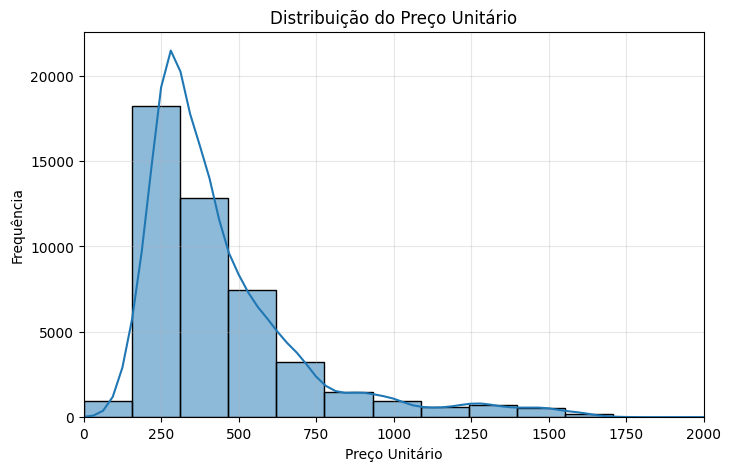

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df['PRECO_UNITARIO'], bins=40, kde=True)

plt.title('Distribuição do Preço Unitário')
plt.xlabel('Preço Unitário')
plt.ylabel('Frequência')

# foco na faixa principal
plt.xlim(0, 2000)

plt.grid(alpha=0.3)
plt.show()

A distribuição do PRECO_UNITARIO evidencia concentração em faixas específicas, principalmente entre aproximadamente 200 e 500, indicando uma padronização na estratégia de precificação da categoria analisada.

Apesar dessa concentração, observa-se a presença de uma cauda longa à direita, com valores mais elevados ocorrendo com menor frequência, o que pode estar associado a produtos premium ou variações específicas dentro da categoria.

Esse comportamento sugere que, embora exista variação de preços, ela ocorre de forma controlada e segmentada, o que pode influenciar diretamente a dinâmica de demanda.

## 3.2- Relação entre variáveis

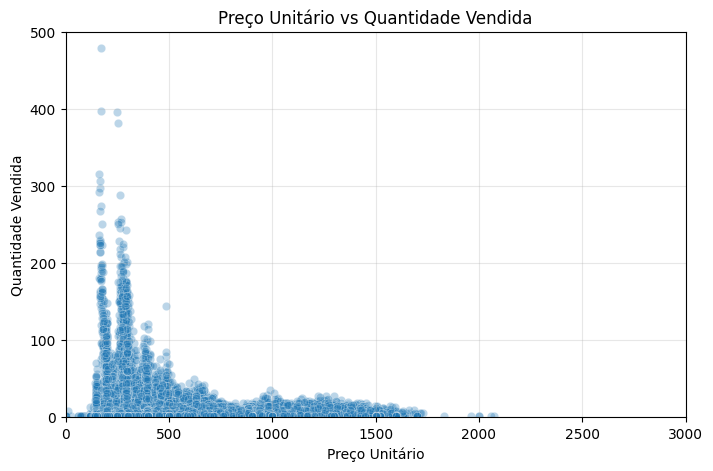

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df['PRECO_UNITARIO'],
    y=df['QUANTIDADE_VENDIDA'],
    alpha=0.3
)

plt.title('Preço Unitário vs Quantidade Vendida')
plt.xlabel('Preço Unitário')
plt.ylabel('Quantidade Vendida')

plt.xlim(0, 3000)
plt.ylim(0, 500)

plt.grid(alpha=0.3)
plt.show()

O gráfico de dispersão entre PRECO_UNITARIO e QUANTIDADE_VENDIDA evidencia um padrão de comportamento em que maiores volumes de venda estão concentrados em faixas de preço mais baixas.

Observa-se que, à medida que o preço aumenta, a quantidade vendida tende a se reduzir e se concentrar em valores baixos, sugerindo uma relação inversa entre preço e demanda.

No entanto, a relação não se apresenta de forma linear, sendo caracterizada por alta dispersão, o que indica que outros fatores além do preço também influenciam o volume de vendas.

Esse comportamento sugere a existência de elasticidade da demanda, ainda que não perfeitamente definida, reforçando o potencial de aplicação de modelos de Machine Learning para capturar padrões mais complexos entre preço e quantidade vendida.

## 3.3- Boxplot

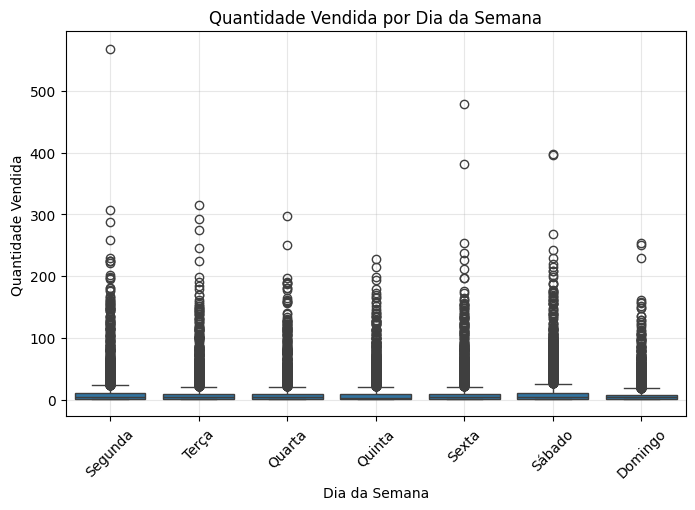

In [ ]:
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

plt.figure(figsize=(8, 5))

sns.boxplot(
    x='NOME_DIA',
    y='QUANTIDADE_VENDIDA',
    data=df,
    order=ordem_dias
)

plt.title('Quantidade Vendida por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Quantidade Vendida')

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

## ANALISE TEMPORAL

A análise da quantidade vendida por dia da semana indica que o comportamento das vendas é relativamente homogêneo ao longo dos dias.

As medianas e a dispersão dos dados apresentam valores semelhantes entre os diferentes dias da semana, sugerindo ausência de variações significativas no volume de vendas.

Embora existam alguns valores extremos (outliers) em todos os dias, esses não caracterizam um padrão específico associado a um dia da semana.

Dessa forma, não se observa evidência clara de que o dia da semana, isoladamente, seja um fator determinante para a quantidade vendida.

Esse comportamento sugere que a variável DIA_SEMANA pode ter baixo poder explicativo isoladamente no modelo, sendo possivelmente mais relevante quando combinada com outras variáveis.

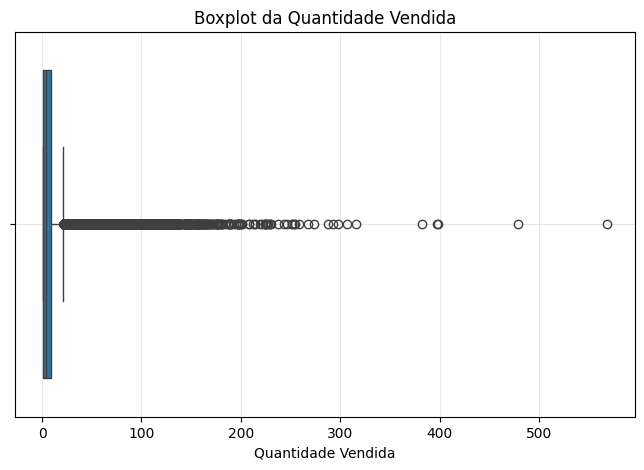

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df['QUANTIDADE_VENDIDA'])

plt.title('Boxplot da Quantidade Vendida')
plt.xlabel('Quantidade Vendida')

plt.grid(alpha=0.3)
plt.show()

O boxplot da variável QUANTIDADE_VENDIDA evidencia forte concentração dos dados em valores baixos, com presença significativa de outliers.

Esses valores extremos representam dias com volumes de venda mais elevados, que, embora menos frequentes, impactam a distribuição da variável e podem influenciar análises e modelos preditivos.

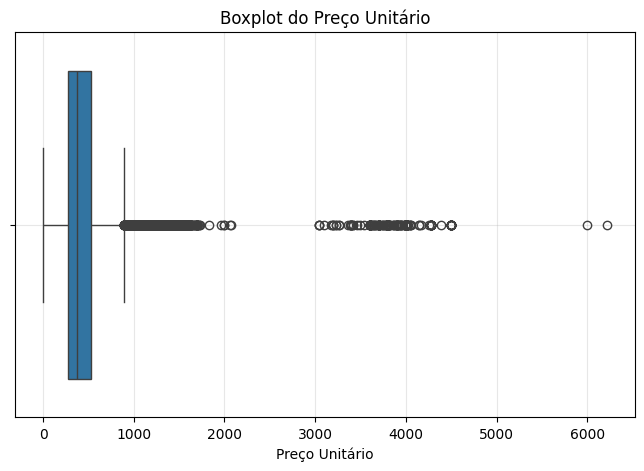

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df['PRECO_UNITARIO'])

plt.title('Boxplot do Preço Unitário')
plt.xlabel('Preço Unitário')

plt.grid(alpha=0.3)
plt.show()

O boxplot do PRECO_UNITARIO revela concentração dos valores em faixas específicas, com presença de outliers em níveis mais elevados de preço.

Esses valores extremos podem estar associados a produtos diferenciados ou variações pontuais de preço, sendo relevantes para a compreensão da distribuição da variável.

- Conclusão

A presença de outliers tanto na quantidade vendida quanto no preço unitário indica a necessidade de avaliação cuidadosa dessas observações na etapa de pré-processamento, uma vez que podem impactar diretamente o desempenho de modelos de Machine Learning.


In [ ]:
# estatísticas descritivas básicas do dataset
df.describe()

,DATA_EMISSAO,SKU,QUANTIDADE_VENDIDA,VALOR_TOTAL,PRECO_UNITARIO,ANO,MES,DIA_SEMANA,FIM_DE_SEMANA
count,47426,4.742600e+04,47426.000000,47426.000000,47426.000000,47426.000000,47426.000000,47426.000000,47426.000000
mean,2025-09-16 09:42:09.093746176,1.851265e+10,9.066672,3554.171381,466.648520,2025.192595,6.733543,2.992283,0.285982
min,2025-03-01 00:00:00,1.000246e+10,1.000000,0.040000,0.040000,2025.000000,1.000000,0.000000,0.000000
25%,2025-06-25 00:00:00,1.849203e+10,1.000000,549.900000,278.900000,2025.000000,3.000000,1.000000,0.000000
50%,2025-09-20 00:00:00,1.860107e+10,4.000000,1499.900000,373.655000,2025.000000,7.000000,3.000000,0.000000
75%,2025-12-11 00:00:00,1.868446e+10,9.000000,4303.662500,524.910000,2025.000000,10.000000,5.000000,1.000000
max,2026-03-22 00:00:00,2.203395e+11,568.000000,99572.420000,6214.140000,2026.000000,12.000000,6.000000,1.000000
std,NaN,1.648528e+09,17.896797,5395.262377,383.634202,0.394342,3.477909,1.988492,0.451886


## 3.4- Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

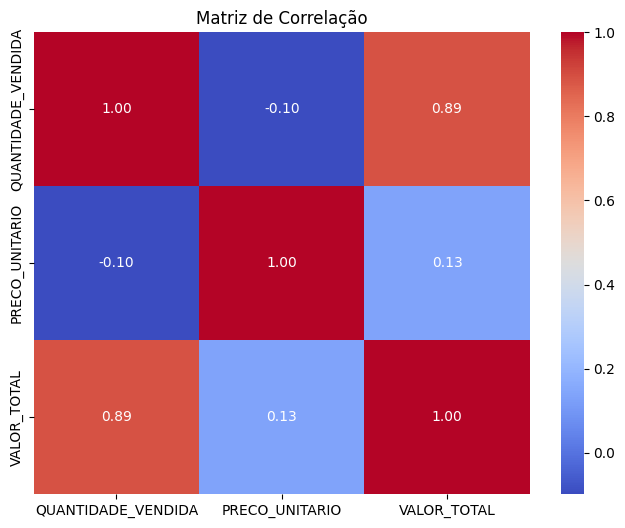

In [ ]:
plt.figure(figsize=(8, 6))

corr = df[['QUANTIDADE_VENDIDA', 'PRECO_UNITARIO', 'VALOR_TOTAL']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title('Matriz de Correlação')
plt.show()

A matriz de correlação permite avaliar a relação linear entre as variáveis numéricas do dataset.

Observa-se forte correlação entre VALOR_TOTAL e QUANTIDADE_VENDIDA, o que é esperado, uma vez que o valor total é diretamente influenciado pelo volume de vendas.

Já a relação entre PRECO_UNITARIO e QUANTIDADE_VENDIDA apresenta baixa correlação linear, indicando que a relação entre essas variáveis não é simples e pode envolver padrões não lineares.

Esse resultado está alinhado com a análise visual realizada anteriormente, reforçando a necessidade de utilização de modelos mais robustos para capturar o comportamento da demanda.

In [ ]:
top_skus = (
    df.groupby('DESCRI_SKU')['VALOR_TOTAL']
    .sum()
    .sort_values(ascending=False)
    .head(5)   # você pode testar 5 ou 10
    .index
)

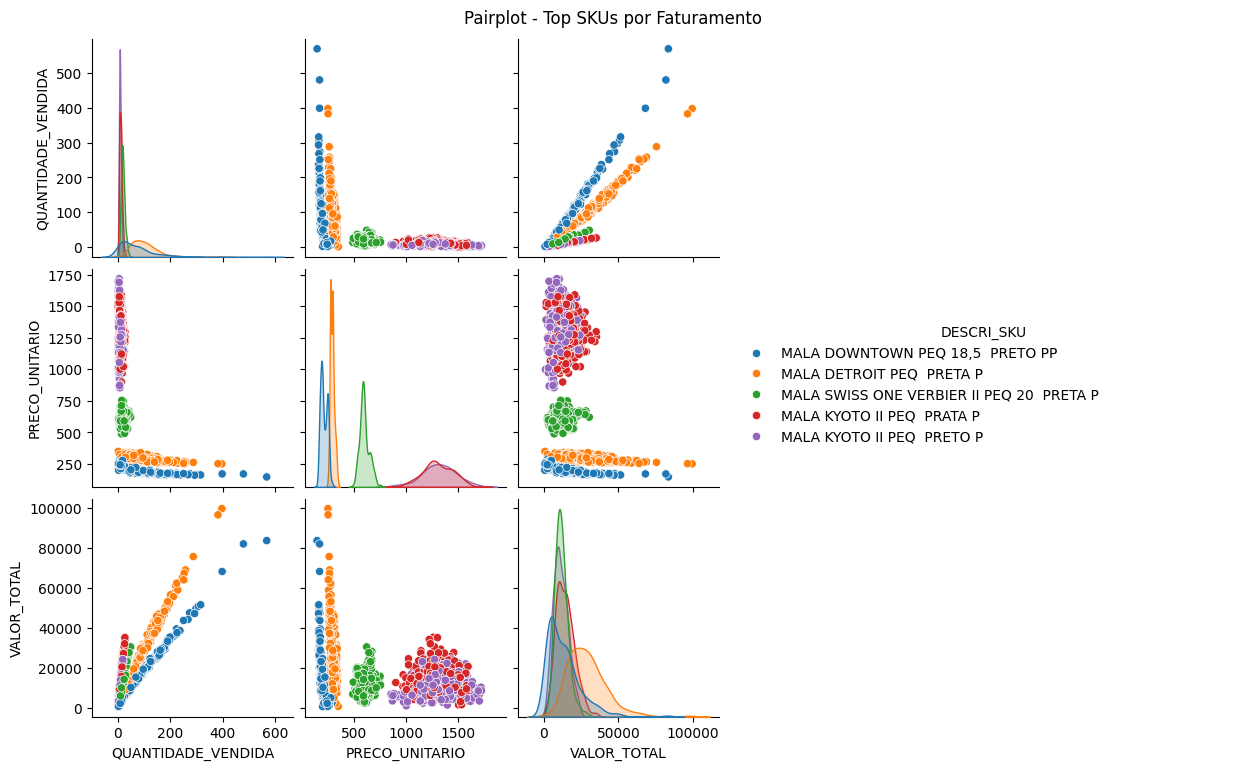

In [ ]:
df_top = df[df['DESCRI_SKU'].isin(top_skus)]

sns.pairplot(
    df_top[['QUANTIDADE_VENDIDA', 'PRECO_UNITARIO', 'VALOR_TOTAL', 'DESCRI_SKU']],
    hue='DESCRI_SKU' ,  palette='tab10'
)

plt.suptitle('Pairplot - Top SKUs por Faturamento', y=1.02)
plt.show()

A análise do pairplot segmentado por SKU evidencia a existência de diferentes padrões de comportamento entre os produtos analisados.

Observa-se que os SKUs se distribuem em faixas distintas de preço e volume de vendas, indicando diferentes posicionamentos de mercado, como produtos de maior volume em faixas de preço mais baixas e produtos premium com preços mais elevados e menor volume.

Além disso, a relação entre preço e quantidade vendida varia entre os produtos, sugerindo que a elasticidade da demanda não é uniforme entre os SKUs.

Esse comportamento reforça a complexidade do problema e indica que a modelagem da demanda deve considerar as diferenças entre produtos para capturar de forma mais precisa os padrões de vendas.Com base nesse insight, será incorporada na etapa de pré-processamento uma variável de cluster de preço proveniente do cadastro de produtos da empresa, com o objetivo de capturar essas diferenças estruturais.

#4- Pré-Processamento de Dados




# 4.1- Feature Engineering

Criação de uma nova variável com o objetivo de enriquecer a base de dados e melhorar a representação das características dos produtos.

A variável CLUSTER_PRECO foi construída a partir do preço médio de cada SKU ao longo do período analisado, permitindo segmentar os produtos em três grupos (P1, P2 e P3), que representam diferentes faixas de preço.

Essa abordagem foi adotada para reduzir o impacto de variações pontuais de preço, como promoções, garantindo uma representação mais estável do posicionamento dos produtos.

A inclusão dessa variável contribui para capturar diferenças estruturais entre os SKUs, conforme observado na análise exploratória, podendo auxiliar na explicação dos padrões de venda.

In [ ]:

#  Criação da variável CLUSTER_PRECO


# 1. Calcular preço médio por SKU
preco_medio_sku = (
    df.groupby('SKU')['PRECO_UNITARIO']
    .mean()
    .reset_index()
)

# 2. Criar clusters (P1, P2, P3)
preco_medio_sku['CLUSTER_PRECO'] = pd.qcut(
    preco_medio_sku['PRECO_UNITARIO'],
    q=3,
    labels=['P1', 'P2', 'P3']
)

# 3. Juntar com a base original
df = df.merge(
    preco_medio_sku[['SKU', 'CLUSTER_PRECO']],
    on='SKU',
    how='left'
)

# 4. Conferir
df[['SKU', 'PRECO_UNITARIO', 'CLUSTER_PRECO']].head()

,SKU,PRECO_UNITARIO,CLUSTER_PRECO
0,18682458002,177.75,P1
1,18601458003,603.17,P3
2,18465651003,399.90,P3
3,18433586003,508.03,P3
4,18405458003,371.08,P2


In [ ]:
df['CLUSTER_PRECO'].value_counts()

,count
CLUSTER_PRECO,
P3,25211
P2,17083
P1,5132


In [ ]:
validacao = (
    df.groupby('SKU')['CLUSTER_PRECO']
    .nunique()
    .reset_index()
)

# verificar SKUs com mais de 1 cluster
inconsistentes = validacao[validacao['CLUSTER_PRECO'] > 1]

inconsistentes.head()

,SKU,CLUSTER_PRECO


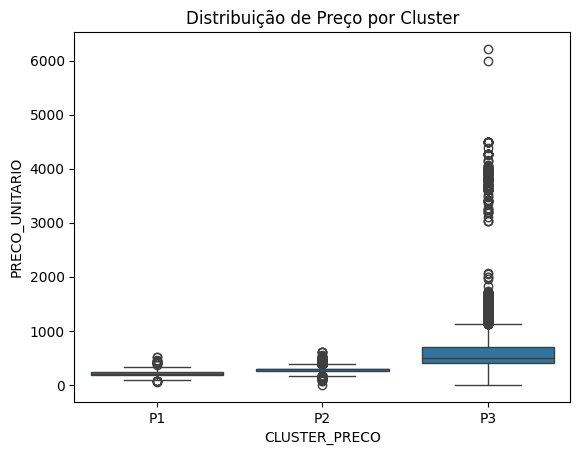

In [ ]:
sns.boxplot(x='CLUSTER_PRECO', y='PRECO_UNITARIO', data=df)
plt.title('Distribuição de Preço por Cluster')
plt.show()

A variável criada se mostra adequada para representar diferenças estruturais entre os SKUs, podendo contribuir para análises e modelos preditivos.

In [ ]:

#Separar features (X) e target (y)


# Variável alvo
y = df['QUANTIDADE_VENDIDA']

# Variáveis explicativas
X = df.drop(['QUANTIDADE_VENDIDA', 'DATA_EMISSAO', 'DESCRI_SKU', 'NOME_DIA', 'VALOR_TOTAL' ], axis=1)

# Transformar a variável categórica CLUSTER_PRECO em variáveis numéricas
X = pd.get_dummies(X, columns=['CLUSTER_PRECO'], drop_first=True)

# Visualizar as primeiras linhas das features
display(X.head())

,SKU,PRECO_UNITARIO,ANO,MES,DIA_SEMANA,FIM_DE_SEMANA,CLUSTER_PRECO_P2,CLUSTER_PRECO_P3
0,18682458002,177.75,2025,11,4,0,False,False
1,18601458003,603.17,2025,9,4,0,False,True
2,18465651003,399.90,2025,7,0,0,False,True
3,18433586003,508.03,2025,3,3,0,False,True
4,18405458003,371.08,2025,5,6,1,True,False


A variável categórica CLUSTER_PRECO foi transformada em formato numérico por meio de técnicas de codificação (encoding), possibilitando sua utilização em modelos de Machine Learning.

Essa transformação foi realizada através da criação de variáveis binárias (dummies), representando cada categoria de forma adequada sem introduzir relações ordinais indevidas entre os grupos.

In [ ]:

# Dividir os dados em conjuntos de treino e teste

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (33198, 8)
Dimensões de X_test: (14228, 8)
Dimensões de y_train: (33198,)
Dimensões de y_test: (14228,)


Após a preparação das variáveis, os dados foram divididos em conjuntos de treino e teste, permitindo a avaliação do desempenho de modelos em dados não utilizados no treinamento e reduzindo o risco de overfitting.

# 4.2- Feature Selection

Como etapa adicional de pré-processamento, foi realizada uma análise de seleção de características, com o objetivo de evitar redundâncias e possíveis vazamentos de informação.

Nesse contexto, a variável VALOR_TOTAL foi removida do conjunto de dados, por possuir relação direta com a variável alvo (QUANTIDADE_VENDIDA), o que poderia comprometer a validade de modelos preditivos.

Essa etapa contribui para garantir maior robustez e confiabilidade nas análises e futuras modelagens.

Técnicas de normalização e padronização não foram aplicadas nesta etapa, uma vez que o foco esteve na preparação dos dados. Sua utilização pode ser avaliada em etapas futuras de modelagem, especialmente em algoritmos sensíveis à escala das variáveis.

#5- Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1 - A quantidade vendida varia em função do preço ao longo do tempo.

A análise exploratória, especialmente por meio do scatterplot entre preço e quantidade vendida, indica a existência de relação entre as variáveis. No entanto, essa relação se mostrou fraca quando analisada de forma agregada, sugerindo que outros fatores também influenciam a demanda.

Dessa forma, a hipótese é parcialmente confirmada.

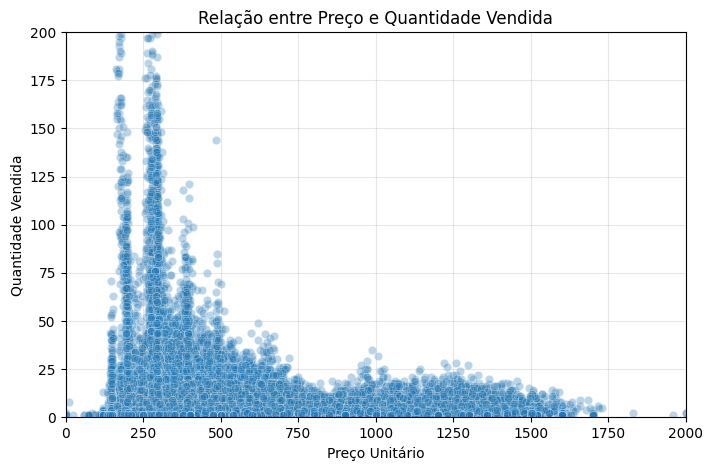

In [ ]:
# hipótese 1

plt.figure(figsize=(8, 5))
sns.scatterplot(x='PRECO_UNITARIO', y='QUANTIDADE_VENDIDA', data=df, alpha=0.3)
plt.title('Relação entre Preço e Quantidade Vendida')
plt.xlabel('Preço Unitário')
plt.ylabel('Quantidade Vendida')
plt.xlim(0, 2000)
plt.ylim(0, 200)
plt.grid(alpha=0.3)
plt.show()

## Hipótese 2 - Reduções de preço estão relacionadas ao aumento da quantidade vendida.

Observou-se que menores faixas de preço estão associadas a maiores volumes de vendas, conforme evidenciado nos gráficos de distribuição e no pairplot por SKU.

Contudo, a ausência de uma variável explícita de promoção impede a confirmação direta dessa relação.

Assim, a hipótese é indiretamente confirmada.

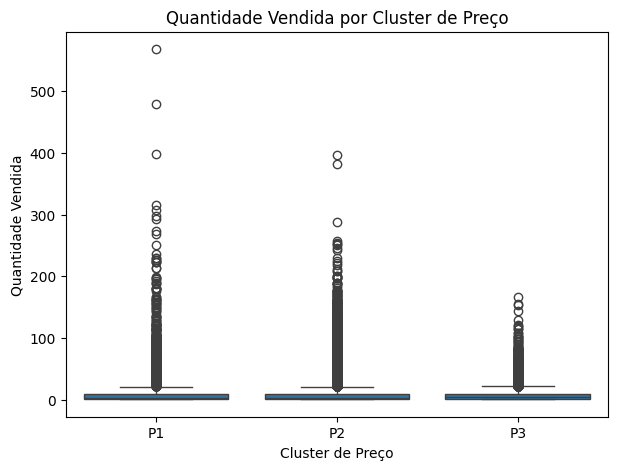

In [ ]:
# hipótese 2

plt.figure(figsize=(7, 5))
sns.boxplot(x='CLUSTER_PRECO', y='QUANTIDADE_VENDIDA', data=df)
plt.title('Quantidade Vendida por Cluster de Preço')
plt.xlabel('Cluster de Preço')
plt.ylabel('Quantidade Vendida')
plt.show()

## Hipótese 3 - A relação entre preço e quantidade não é linear.

A análise visual por meio do scatterplot e do pairplot indica que a relação entre preço e quantidade vendida apresenta comportamentos distintos entre os produtos, não seguindo um padrão linear simples.

Além disso, diferentes SKUs respondem de maneira distinta às variações de preço, indicando heterogeneidade na elasticidade da demanda.

Portanto, a hipótese é confirmada.

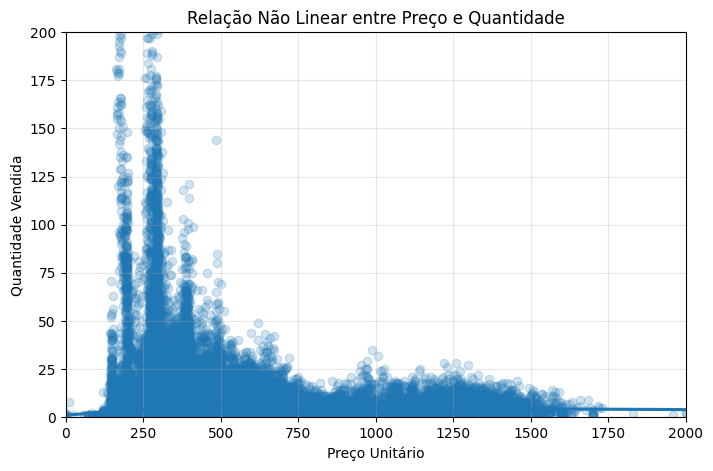

In [ ]:
# hipótese 3

plt.figure(figsize=(8, 5))
sns.regplot(
    x='PRECO_UNITARIO',
    y='QUANTIDADE_VENDIDA',
    data=df,
    scatter_kws={'alpha':0.2},
    lowess=True  # linha suavizada
)
plt.title('Relação Não Linear entre Preço e Quantidade')
plt.xlabel('Preço Unitário')
plt.ylabel('Quantidade Vendida')
plt.xlim(0, 2000)
plt.ylim(0, 200)
plt.grid(alpha=0.3)
plt.show()

## Hipótese 4 - Existem padrões temporais na demanda.

A análise por dia da semana indicou pequenas variações na quantidade vendida, porém sem diferenças significativas entre os dias.

Isso sugere que, embora existam variações temporais, elas não são o principal fator explicativo da demanda neste contexto.

Assim, a hipótese é fracamente confirmada.

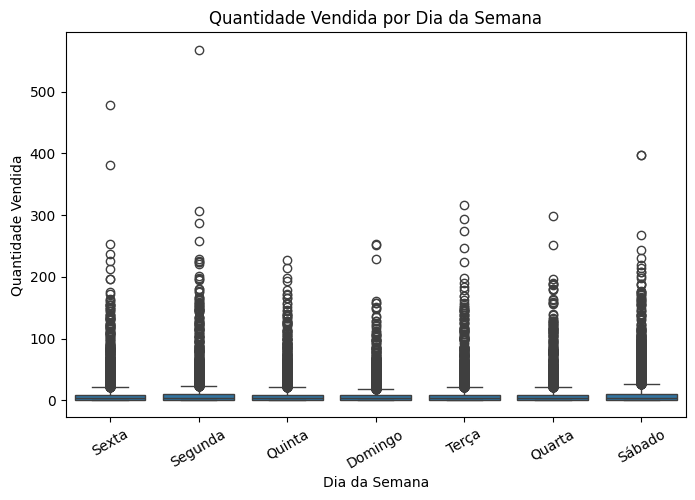

In [ ]:
# hipótese 4

plt.figure(figsize=(8, 5))
sns.boxplot(x='NOME_DIA', y='QUANTIDADE_VENDIDA', data=df)
plt.title('Quantidade Vendida por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Quantidade Vendida')
plt.xticks(rotation=30)
plt.show()

## Hipótese 5 - Existem fatores não observáveis que influenciam a demanda.

A baixa correlação observada entre preço e quantidade vendida, bem como a dispersão dos dados, sugerem a presença de fatores não capturados no dataset, como promoções, disponibilidade de estoque e campanhas comerciais.

Esse comportamento reforça a complexidade do problema e a limitação das variáveis disponíveis.

Dessa forma, a hipótese é confirmada.

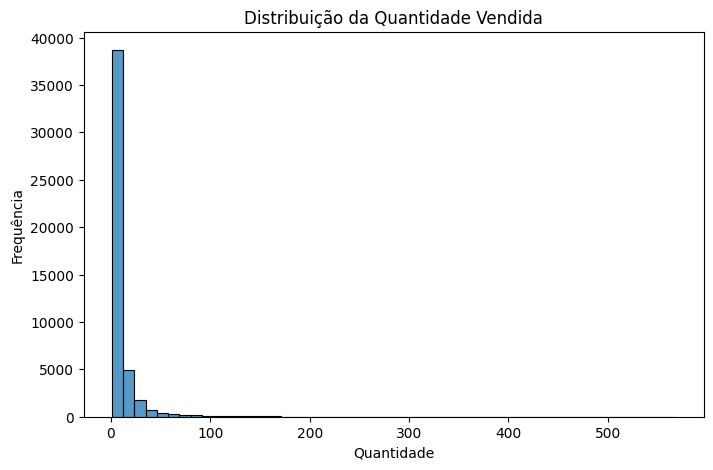

In [ ]:
# hipótese 5
plt.figure(figsize=(8, 5))
sns.histplot(df['QUANTIDADE_VENDIDA'], bins=50)
plt.title('Distribuição da Quantidade Vendida')
plt.xlabel('Quantidade')
plt.ylabel('Frequência')
plt.show()

#6- Conclusão

O trabalho teve como objetivo analisar o comportamento da demanda de malas de bordo a partir de variáveis como preço, tempo e características dos produtos.

A análise exploratória permitiu identificar padrões relevantes, como a existência de diferentes comportamentos entre os SKUs, a influência parcial do preço sobre a quantidade vendida e a presença de fatores não observáveis que impactam a demanda.

A criação da variável CLUSTER_PRECO se mostrou uma abordagem eficaz para segmentar os produtos em diferentes faixas de preço, permitindo capturar diferenças estruturais entre os itens e enriquecer a análise.

Além disso, foram realizadas etapas de pré-processamento, incluindo transformação de variáveis categóricas e seleção de características, garantindo maior consistência e adequação da base para futuras aplicações de modelos preditivos.

Por fim, os resultados indicam que a modelagem da demanda nesse contexto é um problema complexo, influenciado por múltiplos fatores, o que reforça a importância da inclusão de novas variáveis, como informações de promoção e estoque, em análises futuras.

Dessa forma, a base construída encontra-se preparada para o desenvolvimento de modelos de Machine Learning, possibilitando avanços na compreensão e previsão da demanda no varejo.